In [9]:
# ===========================
#  Merge the data
#  Supplementary analysis by race
# ===========================
import pandas as pd
from pathlib import Path

OUT_DIR    = Path("outputs")
ID_COL     = "essay_id_comp"
GROUP_COL  = "race_binary"
TARGET_COL = "holistic_essay_score_3cat"

# ---------------------------
# Load test set ground truth
# ---------------------------
test_df = pd.read_csv(
    OUT_DIR / "test_split.csv",
    usecols=[ID_COL, TARGET_COL]
)

# ---------------------------
# Load cleaned full dataset
# to recover race_ethnicity
# ---------------------------
full_df = pd.read_csv(
    "./data/persuade_clean.csv",
    usecols=[ID_COL, "race_ethnicity"]
)

# ---------------------------
# Recode race: White vs. non-White
# ---------------------------
full_df[GROUP_COL] = full_df["race_ethnicity"].apply(
    lambda x: "White"
    if pd.notna(x) and str(x).strip() == "White"
    else ("non-White" if pd.notna(x) else pd.NA)
)

full_df = full_df[[ID_COL, GROUP_COL]].dropna(subset=[GROUP_COL]).copy()

# ---------------------------
# Merge race info into test set
# ---------------------------
test_df = test_df.merge(full_df, on=ID_COL, how="left")
test_df = test_df.dropna(subset=[GROUP_COL]).copy()

# ---------------------------
# Prediction files
# ---------------------------
pred_paths = {
    "tfidf":            OUT_DIR / "scores_tfidf_ordlogit_cv.csv",
    "bert":             OUT_DIR / "scores_bert_ord.csv",
    "chatgpt_zeroshot": OUT_DIR / "scores_chatgpt_zeroshot.csv",
    "chatgpt_fewshot":  OUT_DIR / "scores_chatgpt_fewshot.csv",
}

dfs = []
for model_key, path in pred_paths.items():
    df = pd.read_csv(path)
    pred_col = [c for c in df.columns if c.startswith("y_pred")][0]
    df = df[[ID_COL, pred_col]].rename(columns={pred_col: f"y_pred_{model_key}"})
    dfs.append(df)

# ---------------------------
# Merge all predictions onto the test set
# ---------------------------
merged = test_df.copy()
for mdf in dfs:
    merged = merged.merge(mdf, on=ID_COL, how="left")

merged_path = OUT_DIR / "scores_merged_test_race.csv"
merged.to_csv(merged_path, index=False)

print(">>> Merge complete (TEST only; supplementary race analysis)")
print("Shape:", merged.shape)
print("Columns:", list(merged.columns))

print("\n=== Race group distribution in merged test set ===")
display(
    pd.concat(
        [
            merged[GROUP_COL].value_counts(dropna=False).rename("count"),
            merged[GROUP_COL].value_counts(normalize=True, dropna=False).mul(100).round(2).rename("percent")
        ],
        axis=1
    )
)

>>> Merge complete (TEST only; supplementary race analysis)
Shape: (434, 7)
Columns: ['essay_id_comp', 'holistic_essay_score_3cat', 'race_binary', 'y_pred_tfidf', 'y_pred_bert', 'y_pred_chatgpt_zeroshot', 'y_pred_chatgpt_fewshot']

=== Race group distribution in merged test set ===


,count,percent
race_binary,,
non-White,253,58.29
White,181,41.71


In [10]:
merged.head()

,essay_id_comp,holistic_essay_score_3cat,race_binary,y_pred_tfidf,y_pred_bert,y_pred_chatgpt_zeroshot,y_pred_chatgpt_fewshot
0,7F220FD6CACF,1,non-White,1,2,1,1
1,B3FE48815543,3,White,3,3,2,2
2,B6428F6EB5F3,2,non-White,2,2,2,2
3,5D4E78CE6D5F,2,non-White,2,2,1,2
4,EA48C80121AD,2,White,1,1,1,1


In [11]:
# ===========================
#  Block 1 — Agreement (Kappa & QWK)
# ===========================
from sklearn.metrics import cohen_kappa_score
import pandas as pd

MODEL_COLS = {
    "tfidf": "y_pred_tfidf",
    "bert": "y_pred_bert",
    "chatgpt_zeroshot": "y_pred_chatgpt_zeroshot",
    "chatgpt_fewshot": "y_pred_chatgpt_fewshot",
}

def _pair_clean(y_true, y_pred):
    s = pd.concat([y_true, y_pred], axis=1).dropna()
    return s.iloc[:, 0].astype(int), s.iloc[:, 1].astype(int)

rows = []
for name, col in MODEL_COLS.items():
    yt, yp = _pair_clean(merged[TARGET_COL], merged[col])
    kappa_plain = cohen_kappa_score(yt, yp)
    kappa_quadr = cohen_kappa_score(yt, yp, weights="quadratic")
    rows.append([name, kappa_plain, kappa_quadr])

block1_df = pd.DataFrame(rows, columns=["model", "kappa", "qwk"]).set_index("model")
print("\n=== Block 1 — Agreement (vs. holistic_essay_score_3cat) ===")
print(block1_df.round(3))


=== Block 1 — Agreement (vs. holistic_essay_score_3cat) ===
                  kappa    qwk
model                         
tfidf             0.632  0.729
bert              0.731  0.799
chatgpt_zeroshot  0.254  0.400
chatgpt_fewshot   0.385  0.505


In [12]:
# ===========================
#  Block 2 — Fairness: Disparity Ratio (Uncond., Cond@1..3)
# ===========================
import numpy as np
import pandas as pd

true_band = merged[TARGET_COL].astype("Int64")

def _dr_for_subset(pred_series, sub_idx, r):
    """
    DR for event A_r: (pred == r) within subset sub_idx.
    DR = P(A_r|White) / P(A_r|non-White).
    """
    idx = merged.index.intersection(pd.Index(sub_idx))
    if len(idx) == 0:
        return np.nan

    idx_w  = idx[merged.loc[idx, GROUP_COL] == "White"]
    idx_nw = idx[merged.loc[idx, GROUP_COL] == "non-White"]

    n_w, n_nw = len(idx_w), len(idx_nw)
    if n_w == 0 or n_nw == 0:
        return np.nan

    num_w  = int((pred_series.loc[idx_w] == r).sum())
    num_nw = int((pred_series.loc[idx_nw] == r).sum())

    p_w  = num_w / n_w
    p_nw = num_nw / n_nw

    if p_nw == 0:
        return np.nan

    return p_w / p_nw

def dr_table_for_model(pred_col):
    pred = merged[pred_col].astype("Int64")

    subsets = {
        "Uncond.": merged.index,
        "Cond@1": merged.index[true_band == 1],
        "Cond@2": merged.index[true_band == 2],
        "Cond@3": merged.index[true_band == 3],
    }

    dr_grid = {r: {} for r in (1, 2, 3)}
    for r in (1, 2, 3):
        for col_name, sub_idx in subsets.items():
            dr_grid[r][col_name] = _dr_for_subset(pred, sub_idx, r)

    rows = []
    for r in (1, 2, 3):
        rows.append([
            f"Pred={r}",
            dr_grid[r]["Uncond."],
            dr_grid[r]["Cond@1"],
            dr_grid[r]["Cond@2"],
            dr_grid[r]["Cond@3"],
        ])

    return (
        pd.DataFrame(rows, columns=["Row", "Uncond.", "Cond@1", "Cond@2", "Cond@3"])
        .set_index("Row")
    )

for model_name, col in MODEL_COLS.items():
    table = dr_table_for_model(col)
    print(f"\n=== Block 2 — DR (no summary) — {model_name} ===")
    print(table.round(3))


=== Block 2 — DR (no summary) — tfidf ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1    0.603   0.925   0.382     NaN
Pred=2    1.255   1.385   1.138   1.677
Pred=3    1.644     NaN   0.876   0.699

=== Block 2 — DR (no summary) — bert ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1    0.691   0.946   0.935     NaN
Pred=2    1.028   1.215   0.972   1.398
Pred=3    2.796     NaN   2.337   0.881

=== Block 2 — DR (no summary) — chatgpt_zeroshot ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1    0.740   1.053   0.701   0.629
Pred=2    1.706   0.436   1.548   1.067
Pred=3      NaN     NaN     NaN     NaN

=== Block 2 — DR (no summary) — chatgpt_fewshot ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1    0.663   0.902   0.673     NaN
Pred=2    1.374   1.501   1.190   0.903
Pred=3      NaN     NaN     NaN     NaN


In [13]:
# ===========================
#  Block 2 — Fairness: Disparity Difference (Uncond., Cond@1..3)
# ===========================
import numpy as np
import pandas as pd

true_band = merged[TARGET_COL].astype("Int64")

def _dd_for_subset(pred_series, sub_idx, r):
    """
    DD_r(S) = P(pred=r | White, S) - P(pred=r | non-White, S).
    """
    idx = merged.index.intersection(pd.Index(sub_idx))
    if len(idx) == 0:
        return np.nan

    idx_w  = idx[merged.loc[idx, GROUP_COL] == "White"]
    idx_nw = idx[merged.loc[idx, GROUP_COL] == "non-White"]

    n_w, n_nw = len(idx_w), len(idx_nw)
    if n_w == 0 or n_nw == 0:
        return np.nan

    num_w  = int((pred_series.loc[idx_w] == r).sum())
    num_nw = int((pred_series.loc[idx_nw] == r).sum())

    p_w  = num_w / n_w
    p_nw = num_nw / n_nw

    return p_w - p_nw

def dd_table_for_model(pred_col):
    pred = merged[pred_col].astype("Int64")

    subsets = {
        "Uncond.": merged.index,
        "Cond@1": merged.index[true_band == 1],
        "Cond@2": merged.index[true_band == 2],
        "Cond@3": merged.index[true_band == 3],
    }

    dd_grid = {r: {} for r in (1, 2, 3)}
    for r in (1, 2, 3):
        for col_name, sub_idx in subsets.items():
            dd_grid[r][col_name] = _dd_for_subset(pred, sub_idx, r)

    rows = []
    for r in (1, 2, 3):
        rows.append([
            f"Pred={r}",
            dd_grid[r]["Uncond."],
            dd_grid[r]["Cond@1"],
            dd_grid[r]["Cond@2"],
            dd_grid[r]["Cond@3"],
        ])

    return (
        pd.DataFrame(rows, columns=["Row", "Uncond.", "Cond@1", "Cond@2", "Cond@3"])
        .set_index("Row")
    )

for model_name, col in MODEL_COLS.items():
    table = dd_table_for_model(col)
    print(f"\n=== Block 2 — DD (no summary) — {model_name} ===")
    print(table.round(3))


=== Block 2 — DD (no summary) — tfidf ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1   -0.171  -0.063  -0.100   0.000
Pred=2    0.128   0.063   0.107   0.208
Pred=3    0.043   0.000  -0.007  -0.208

=== Block 2 — DD (no summary) — bert ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1   -0.109  -0.043  -0.003   0.000
Pred=2    0.016   0.043  -0.027   0.092
Pred=3    0.092   0.000   0.029  -0.092

=== Block 2 — DD (no summary) — chatgpt_zeroshot ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1    -0.19   0.049  -0.193  -0.057
Pred=2     0.19  -0.049   0.193   0.057
Pred=3     0.00   0.000   0.000   0.000

=== Block 2 — DD (no summary) — chatgpt_fewshot ===
        Uncond.  Cond@1  Cond@2  Cond@3
Row                                    
Pred=1   -0.182  -0.082   -0.12   0.032
Pred=2    0.171   0.082    0.12  -0.097
Pred=3    0.011   0.000    0.00   0.065


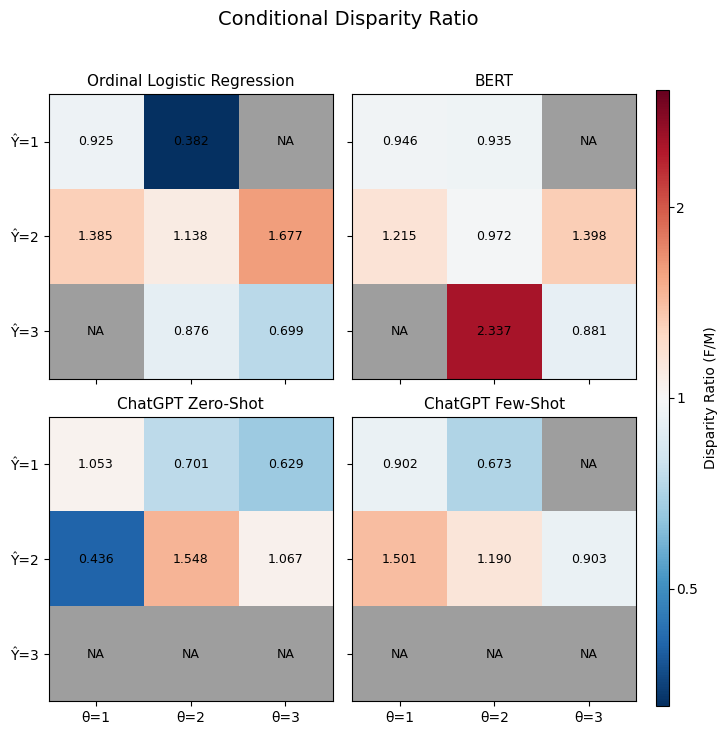

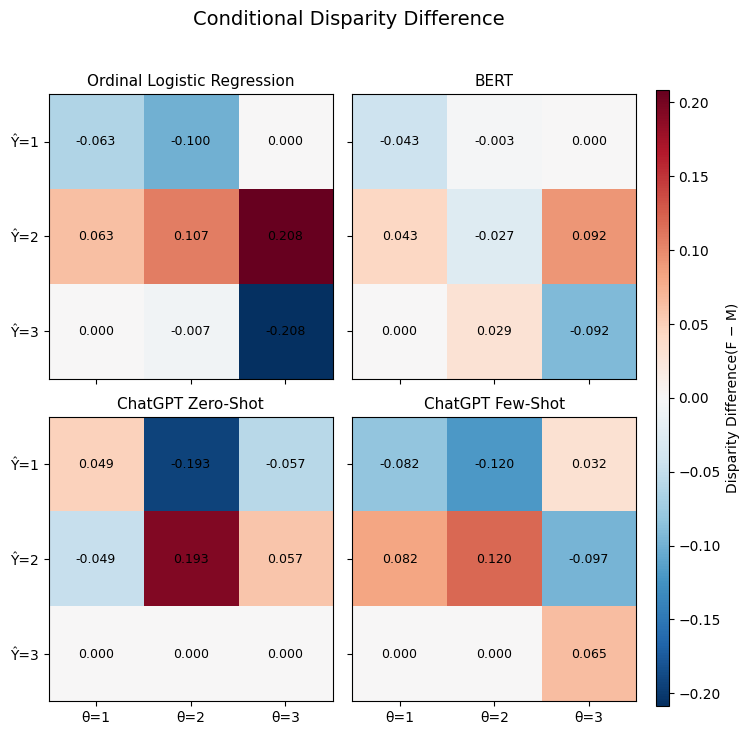

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Panel titles used in the paper (object name -> display name)
TITLE_MAP = {
    "tfidf": "Ordinal Logistic Regression",
    "bert": "BERT",
    "chatgpt_zeroshot": "ChatGPT Zero-Shot",
    "chatgpt_fewshot": "ChatGPT Few-Shot",
}


# Tick labels only (no axis labels)
X_TICKS = ["θ=1", "θ=2", "θ=3"]
Y_TICKS = ["Ŷ=1", "Ŷ=2", "Ŷ=3"]

# -----------------------------
# DR: reciprocal-symmetric transform for coloring (NO log)
# -----------------------------
def _dr_transform(x):
    """
    Reciprocal-symmetric mapping around 1 (center=0):
      if x >= 1:  t = x - 1
      if x <  1:  t = -(1/x - 1)

    Properties:
      - t(1) = 0 (white)
      - t(2) = +1 and t(0.5) = -1  (equal intensity, opposite direction)
    """
    x = np.asarray(x, dtype=float)
    t = np.full_like(x, np.nan, dtype=float)

    mask = np.isfinite(x) & (x > 0)
    ge1 = mask & (x >= 1)
    lt1 = mask & (x < 1)

    t[ge1] = x[ge1] - 1.0
    t[lt1] = -(1.0 / x[lt1] - 1.0)
    return t

def _dr_tick_to_t(x_tick):
    # convert original DR tick value to transformed axis tick
    if x_tick >= 1:
        return x_tick - 1.0
    else:
        return -(1.0 / x_tick - 1.0)

# -----------------------------
# Shared panel plotter (DR)
# -----------------------------
def _plot_panel_dr(ax, dr_df, title, vmin, vmax, show_y_ticks=True, show_x_ticks=True):
    dr = dr_df.to_numpy(dtype=float)
    t = _dr_transform(dr)  # for coloring

    cmap = plt.cm.RdBu_r.copy()          # center is white
    cmap.set_bad(color="#9E9E9E")   # NA is grey
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    im = ax.imshow(np.ma.masked_invalid(t), cmap=cmap, norm=norm)

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(X_TICKS if show_x_ticks else [])
    ax.set_yticklabels(Y_TICKS if show_y_ticks else [])

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # annotate with ORIGINAL DR (no transform shown to reader)
    for i in range(3):
        for j in range(3):
            val = dr[i, j]
            txt = "NA" if np.isnan(val) else f"{val:.3f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    return im

# -----------------------------
# Shared panel plotter (DD)
# -----------------------------
def _plot_panel_dd(ax, dd_df, title, vmin, vmax, show_y_ticks=True, show_x_ticks=True):
    dd = dd_df.to_numpy(dtype=float)

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color="#9E9E9E")
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    im = ax.imshow(np.ma.masked_invalid(dd), cmap=cmap, norm=norm)

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(X_TICKS if show_x_ticks else [])
    ax.set_yticklabels(Y_TICKS if show_y_ticks else [])

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

    for i in range(3):
        for j in range(3):
            val = dd[i, j]
            txt = "NA" if np.isnan(val) else f"{val:.3f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    return im

# -----------------------------
# DR grid (reciprocal-symmetric coloring, shared scale)
# -----------------------------
def plot_dr_grid_compact_reciprocal(
    dr_mats,
    out_path="DR_all_models.png",
    ncols=2,
    wspace=0.1,
    hspace=0.1,
    cbar_width=0.045,
    cbar_ticks=(0.5, 1, 2, 4)
):
    model_names = list(dr_mats.keys())
    n = len(model_names)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    # global scale in transformed space (symmetric around 0)
    all_t = []
    for m in model_names:
        all_t.append(_dr_transform(dr_mats[m].to_numpy(dtype=float)).reshape(-1))
    all_t = np.concatenate(all_t)
    finite = all_t[np.isfinite(all_t)]
    mabs = np.max(np.abs(finite)) if finite.size else 1.0
    if mabs == 0:
        mabs = 0.01
    vmin, vmax = -mabs, mabs

    fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=ncols + 1,
        width_ratios=[1] * ncols + [cbar_width],
        wspace=wspace,
        hspace=hspace
    )

    im_last = None
    for k, model_name in enumerate(model_names):
        r = k // ncols
        c = k % ncols
        ax = fig.add_subplot(gs[r, c])

        show_y = (c == 0)
        show_x = (r == nrows - 1)

        im_last = _plot_panel_dr(
            ax,
            dr_mats[model_name],
            title=TITLE_MAP.get(model_name, model_name),
            vmin=vmin,
            vmax=vmax,
            show_y_ticks=show_y,
            show_x_ticks=show_x
        )

    # turn off unused slots
    for k in range(n, nrows * ncols):
        r = k // ncols
        c = k % ncols
        ax = fig.add_subplot(gs[r, c])
        ax.axis("off")

    # Colorbar axis (spans all rows)
    cax = fig.add_subplot(gs[:, -1])
    cbar = fig.colorbar(im_last, cax=cax)

    # ---- FIX: keep only ticks that fall within [vmin, vmax] in transformed space ----
    tick_vals = [t for t in cbar_ticks if t > 0]  # original DI ticks, must be >0

    tick_pos = []
    tick_lab = []
    for t in tick_vals:
        pos = _dr_tick_to_t(t)          # map DR -> transformed
        if (pos >= vmin) and (pos <= vmax):
            tick_pos.append(pos)
            tick_lab.append(f"{t:g}")

    # Always ensure DR=1 is shown if it's in range (usually true)
    pos1 = _dr_tick_to_t(1.0)  # 0.0
    if (pos1 >= vmin) and (pos1 <= vmax) and ("1" not in tick_lab):
        tick_pos.append(pos1)
        tick_lab.append("1")

    # sort by position
    order = np.argsort(tick_pos)
    tick_pos = [tick_pos[i] for i in order]
    tick_lab = [tick_lab[i] for i in order]

    cbar.set_ticks(tick_pos)
    cbar.set_ticklabels(tick_lab)
    cbar.set_label("Disparity Ratio (F/M)")

    # Make tick labels readable (prevents the “blank” look)
    cbar.ax.tick_params(labelsize=10, pad=2)


    fig.suptitle("Conditional Disparity Ratio", fontsize=14, y=0.98)

    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# DD grid (linear, shared scale)
# -----------------------------
def plot_dd_grid_compact(
    dd_mats,
    dd_vmin,
    dd_vmax,
    out_path="DD_all_models.png",
    ncols=2,
    wspace=0.1,
    hspace=0.1,
    cbar_width=0.045
):
    model_names = list(dd_mats.keys())
    n = len(model_names)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=ncols + 1,
        width_ratios=[1] * ncols + [cbar_width],
        wspace=wspace,
        hspace=hspace
    )

    im_last = None
    for k, model_name in enumerate(model_names):
        r = k // ncols
        c = k % ncols
        ax = fig.add_subplot(gs[r, c])

        show_y = (c == 0)
        show_x = (r == nrows - 1)

        im_last = _plot_panel_dd(
            ax,
            dd_mats[model_name],
            title=TITLE_MAP.get(model_name, model_name),
            vmin=dd_vmin,
            vmax=dd_vmax,
            show_y_ticks=show_y,
            show_x_ticks=show_x
        )

    for k in range(n, nrows * ncols):
        r = k // ncols
        c = k % ncols
        ax = fig.add_subplot(gs[r, c])
        ax.axis("off")

    cax = fig.add_subplot(gs[:, -1])
    cbar = fig.colorbar(im_last, cax=cax)
    cbar.set_label("Disparity Difference(F − M)")

    fig.suptitle("Conditional Disparity Difference", fontsize=14, y=0.98)

    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()



# -----------------------------
# Calls (top-level)
# -----------------------------
# Build dr_mats for plotting (3x3: Pred=1..3 by Cond@1..3) — no extra printing
dr_mats = {}
for model_name, col in MODEL_COLS.items():
    dr_mats[model_name] = dr_table_for_model(col)[["Cond@1", "Cond@2", "Cond@3"]].astype(float)


# Build dd_mats for plotting (3x3: Pred=1..3 by Cond@1..3) — no extra printing
dd_mats = {}
for model_name, col in MODEL_COLS.items():
    dd_mats[model_name] = dd_table_for_model(col)[["Cond@1", "Cond@2", "Cond@3"]].astype(float)

# Global DD color scale (shared across panels)
_all = np.concatenate([m.to_numpy(dtype=float).reshape(-1) for m in dd_mats.values()])
_all = _all[np.isfinite(_all)]
dd_vmin, dd_vmax = float(_all.min()), float(_all.max())



# DR: reciprocal-symmetric coloring (no log)
plot_dr_grid_compact_reciprocal(
    dr_mats,
    out_path="outputs/s_DR_all_models.png",
    ncols=2,
    cbar_ticks=(0.5, 1, 2, 4)   # you can change to (0.67, 0.8, 1, 1.25, 1.5, 2) etc.
)

# DD: keep linear (0 is white)
plot_dd_grid_compact(
    dd_mats,
    dd_vmin,
    dd_vmax,
    out_path="outputs/s_DD_all_models.png",
    ncols=2
)


In [15]:
# ===========================
#  Block — Regression Fairness Baseline (OSA / OSD / CSD)
#  Following the method description in Loukina et al. (2019)
# ===========================

import numpy as np
import pandas as pd
import statsmodels.api as sm

human = merged[TARGET_COL].astype(float)
group = merged[GROUP_COL]

# set focal group explicitly if needed
if group.dtype == "object":
    # edit this line if your labels are not F/M
    group = (merged[GROUP_COL] == "White").astype(int)

def regression_fairness(pred):

    S = pred.astype(float)
    H = human

    error = S - H
    sq_error = error ** 2

    # -----------------
    # OSA
    # (S-H)^2 ~ group
    # report R^2
    # -----------------
    X = sm.add_constant(group)
    osa_model = sm.OLS(sq_error, X, missing="drop").fit()
    osa = osa_model.rsquared

    # -----------------
    # OSD
    # (S-H) ~ group
    # report R^2
    # -----------------
    osd_model = sm.OLS(error, X, missing="drop").fit()
    osd = osd_model.rsquared

    # -----------------
    # CSD
    # ΔR^2 from nested models
    # (S-H) ~ H
    # (S-H) ~ H + group
    # -----------------
    X1 = sm.add_constant(H)
    m1 = sm.OLS(error, X1, missing="drop").fit()

    X2 = sm.add_constant(pd.concat([H, group], axis=1))
    m2 = sm.OLS(error, X2, missing="drop").fit()

    csd = m2.rsquared - m1.rsquared

    return pd.Series({
        "OSA": osa,
        "OSD": osd,
        "CSD": csd
    })


# run for all models
reg_results = {}

for name, col in MODEL_COLS.items():
    reg_results[name] = regression_fairness(merged[col])

reg_results = pd.DataFrame(reg_results).T

print("\nRegression Fairness (Loukina baseline):")
display(reg_results.round(4))


Regression Fairness (Loukina baseline):


,OSA,OSD,CSD
tfidf,0.0003,0.0007,0.0026
bert,0.0041,0.0023,0.0008
chatgpt_zeroshot,0.0002,0.0018,0.0075
chatgpt_fewshot,0.0041,0.0016,0.0064


In [16]:
# ===========================
#  Block — CSD p-values only
#  nested-model comparison
# ===========================

def csd_pval(pred):

    S = pred.astype(float)
    H = human

    tmp = pd.DataFrame({
        "S": S,
        "H": H,
        "G": group
    }).dropna().copy()

    tmp["error"] = tmp["S"] - tmp["H"]

    # reduced model: error ~ H
    X1 = sm.add_constant(tmp[["H"]])
    m1 = sm.OLS(tmp["error"], X1).fit()

    # full model: error ~ H + G
    X2 = sm.add_constant(tmp[["H", "G"]])
    m2 = sm.OLS(tmp["error"], X2).fit()

    # nested-model F test
    f_stat, p_value, df_diff = m2.compare_f_test(m1)

    return p_value


csd_pvals = {}

for name, col in MODEL_COLS.items():
    csd_pvals[name] = csd_pval(merged[col])

csd_pvals = pd.Series(csd_pvals, name="CSD_p")

print("\nCSD p-values:")
display(csd_pvals.round(4))


CSD p-values:


tfidf               0.2437
bert                0.5312
chatgpt_zeroshot    0.0135
chatgpt_fewshot     0.0303
Name: CSD_p, dtype: float64